In [1]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
import gempy as gp
import gempy_viewer as gpv
import contextily as cx
import openpnm as op
import networkx as nx
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
from matplotlib_scalebar.scalebar import ScaleBar
import random
# import cfpy

Setting Backend To: AvailableBackends.numpy


In [2]:
import utils.common
import utils.conduits
import utils.openkarst_network
import utils.geos
importlib.reload(utils.openkarst_network)
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *
import utils.openkarst_network as okn


In [3]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [152]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=1)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [155]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/edges.csv', index = False)

# Generate Geologic Model

In [ ]:
#TODO: generate cost gradient vertically
nx = grid_parameters['nx']
ny = grid_parameters['ny']
nz = grid_parameters['nz']
geo = np.random.randint(1, 3, size = (nx, ny, nz))
geology_costs = {1 : 0.01,
                 2 : .8}
geology_model = { 1 : True, 2 : True}


In [32]:
#random field
from scipy.ndimage import gaussian_filter

field = np.random.rand(nx, ny, nz)
smooth_field = gaussian_filter(field, sigma=5)
smooth_field = (smooth_field - smooth_field.min()) / (smooth_field.max() - smooth_field.min())

bins = [0.5]   # thresholds
geo = np.digitize(smooth_field, bins) + 1

In [30]:
#banded costs
geo[:,:,:] = 1
thickness = 10
offsets = np.arange(-300, 300, 60)  # This creates an array of offsets from -180 to 180 with a step of 60
i, j = np.indices((nx, ny))
mask_xy = np.abs(i + j -nx) <= thickness
for offset in offsets:
    mask_xy |= np.abs(i+ j - nx - offset) <= thickness

geo[mask_xy] = 2

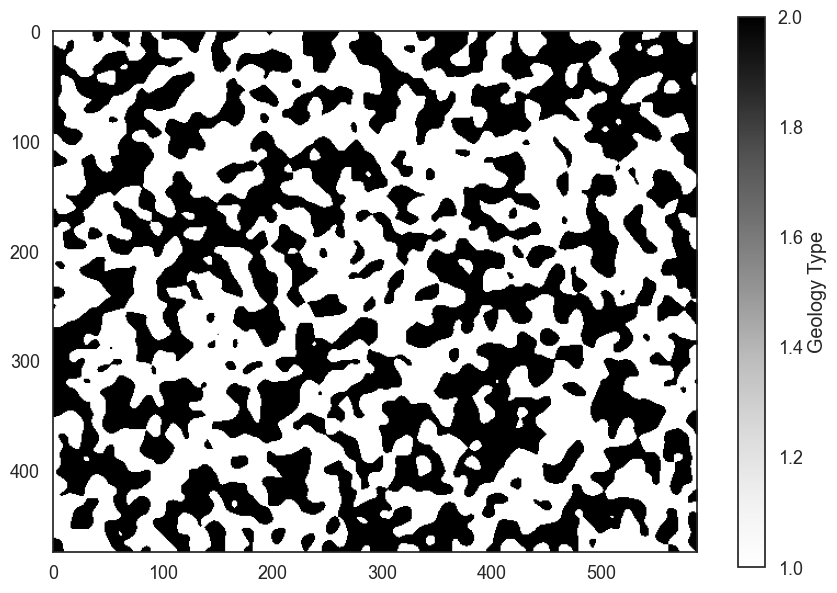

In [35]:
plt.imshow(np.flipud(geo[:,:,2].T))
plt.colorbar(label='Geology Type')

# Generate Network with PyKasso

In [131]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [37]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [36]:
settings = 'dye_trace'

In [ ]:
{'dye_trace' : 
        {'outlets' : {
            'number'     : 1,
            'data'       : [[557689.0, 4869553.0]], #'../../../../data/cave_data/cave_sump.csv',
            'subdomain'  : 'domain',
        },
        'inlets' : {
            'number'     : 8,
            'data'       : '../../../../data/geo_data/sinkholes/sinkholes_dye_trace_2D.txt',#[[558515.0, 4867230.0]], #'../../../../data/geo_data/sinkholes/single_sinkhole_dye_trace.txt',
            'subdomain'  : 'domain_surface',
            'importance' : [4, 3, 1]
        },
        'domain' : {
            'water_level' : np.ones((grid_parameters['nx'], grid_parameters['ny'])) *390 ,  # flat water table at z=375.464m
        },
        'sks' : {'algorithm' : 'Riemann3',
                'karst' : 0.01,
                'geology' : 0.5,
                'fracture' : 0.1,
                'ratio' : 0.1,},

        #TODO: generating vector field for anisotropy
        # 'fractures' : {'generate': 
        #             # 'family_01':{ 'density' : 0.0005 , 'orientation' : 135 , 'dip' : 10, 'length' : 300, 'cost' : 0.1 },  
        #             #     'family_02': { 'density' : 0.0005 , 'orientation' : 45, 'dip' : 10, 'length' : 500, 'cost' : 0.1},
        #                 {'family_03':{ 'density' : 0.0005 , 'orientation' : 135 , 'dip' : 90, 'length' : 300, 'cost' : 0.1 },  
        #                 'family_04': { 'density' : 0.0005 , 'orientation' : 45, 'dip' : 90, 'length' : 500, 'cost' : 0.1}
        #             }
        
        # }
        }
}
        

{'dye_trace': {'outlets': {'number': 1,
   'data': [[557689.0, 4869553.0]],
   'subdomain': 'domain'},
  'inlets': {'number': 8,
   'data': '../../../../data/geo_data/sinkholes/sinkholes_dye_trace_2D.txt',
   'subdomain': 'domain_surface',
   'importance': [4, 3, 1]},
  'domain': {'water_level': array([[390., 390., 390., ..., 390., 390., 390.],
          [390., 390., 390., ..., 390., 390., 390.],
          [390., 390., 390., ..., 390., 390., 390.],
          ...,
          [390., 390., 390., ..., 390., 390., 390.],
          [390., 390., 390., ..., 390., 390., 390.],
          [390., 390., 390., ..., 390., 390., 390.]])},
  'sks': {'algorithm': 'Riemann3',
   'karst': 0.01,
   'geology': 0.5,
   'fracture': 0.1,
   'ratio': 0.1}}}

In [134]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [39]:
azimuth = 350
dip = 0 #np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [40]:
bedrock = grid - 3#assume bedrock is right below surface

In [41]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
model_parameters[settings]['domain']['topography'] = grid.T
model_parameters[settings]['geology'] = {
        'data' : geo,
        'costs' : geology_costs,
        'model' : geology_model
    }
# model_parameters[settings]['domain']['water_table'] = grid.T - 4
# model_parameters[settings]['domain']['bedrock'] = bedrock.T

In [42]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


In [43]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
# nodes['z'] = 395 # set all nodes to the same elevation to create a 2D network
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

In [44]:
nodes, edges = reduce_node_density(nodes, edges, 10)
nodes, edges = reset_node_ids(nodes, edges)
edges = extract_edge_coordinates(nodes, edges)
network = okn.OpenKarstNetwork(nodes = nodes, edges = edges)
network.load_cave_data()

net : <openpnm.network.Network at 0x1d67bec6090>

c:\Users\huan1428\.conda\envs\pyKasso\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning:

Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.



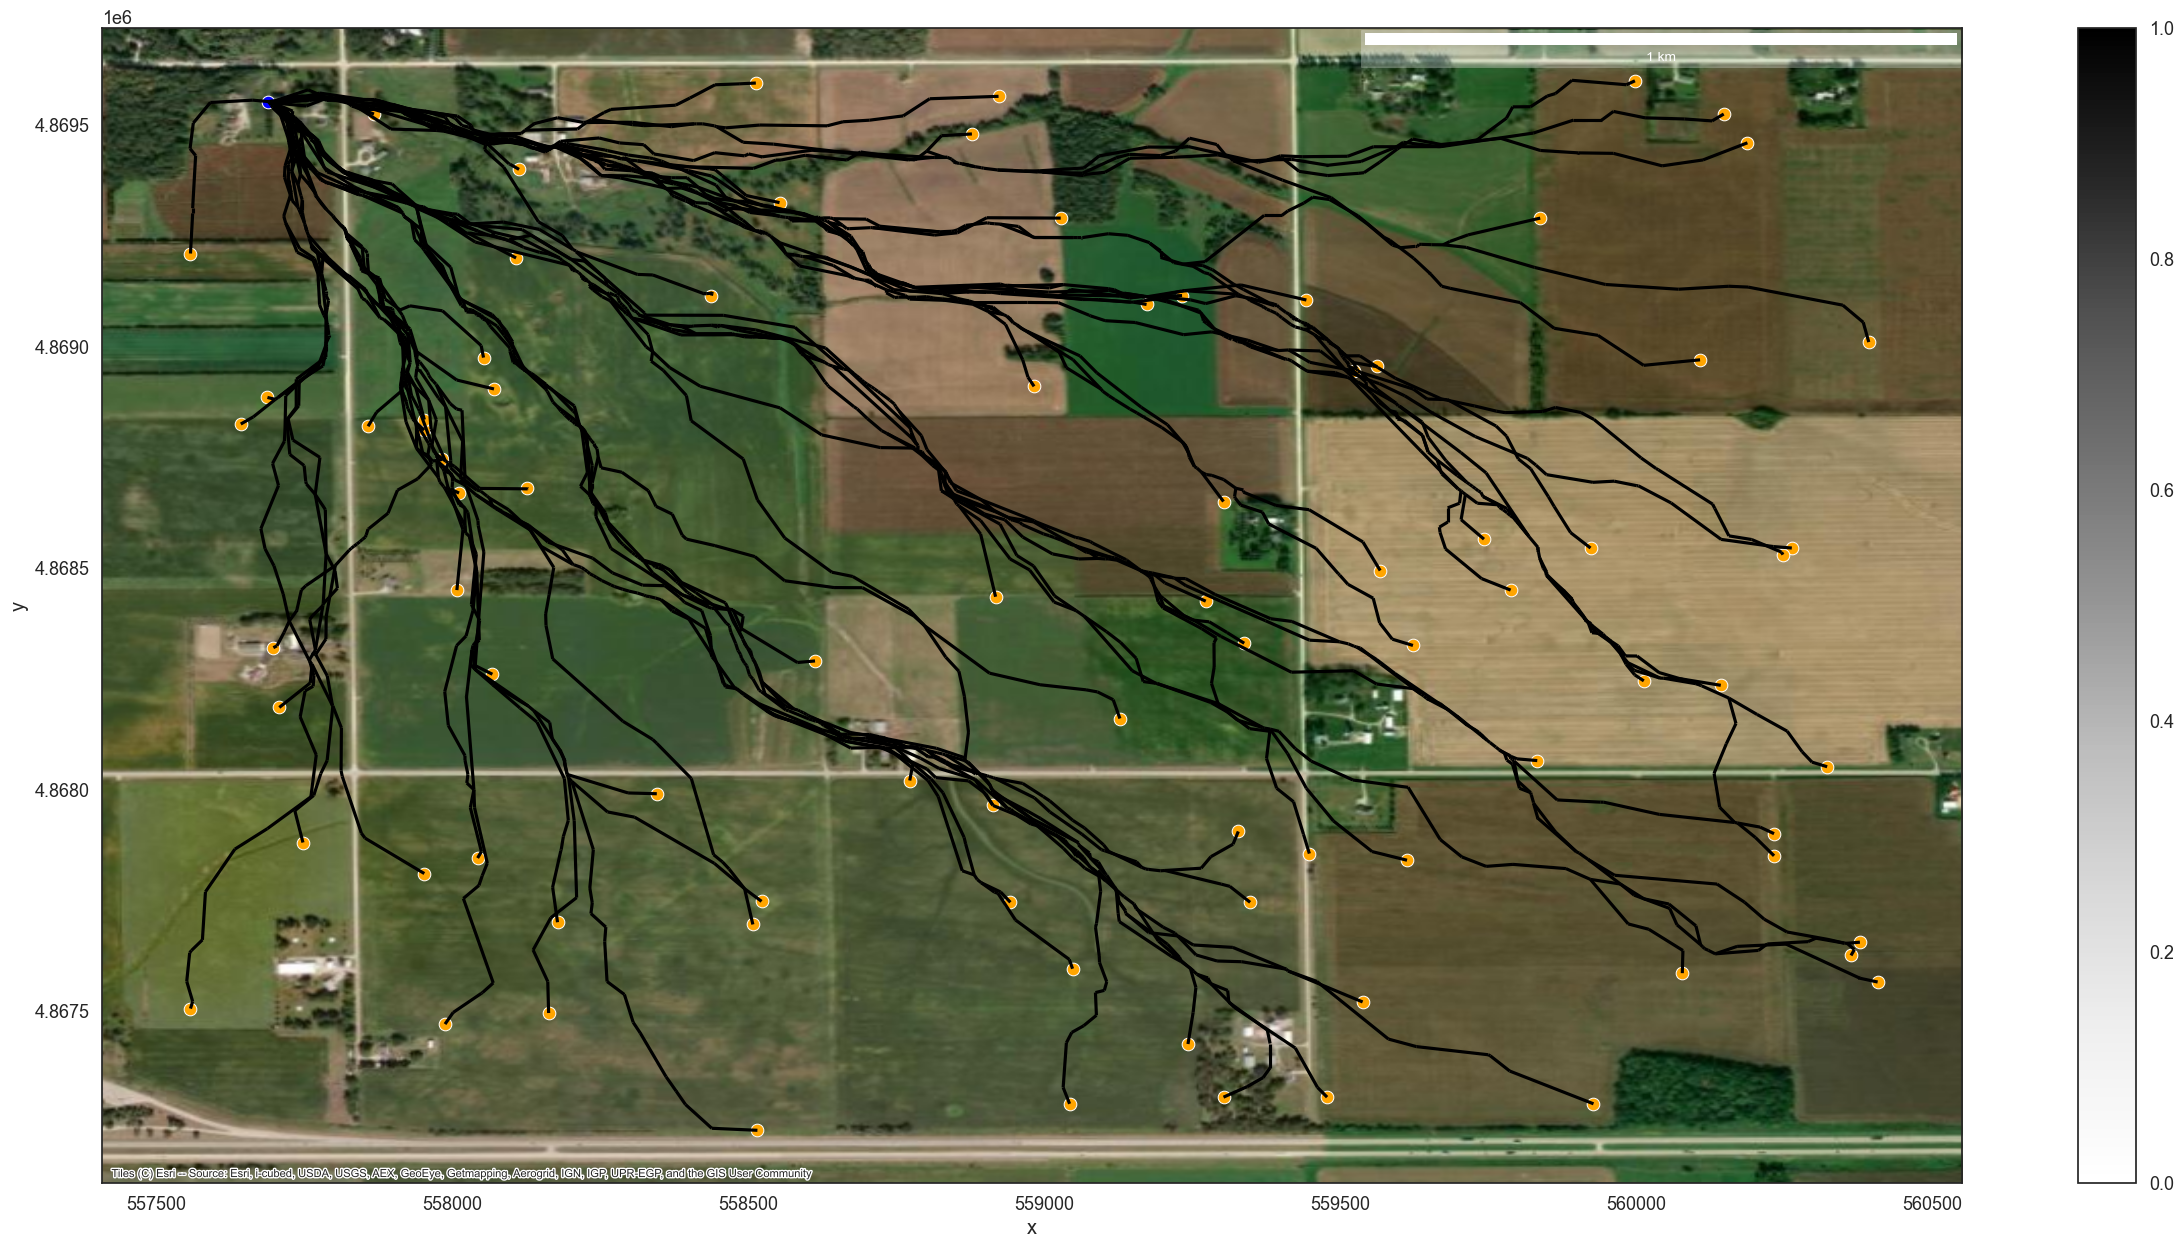

In [268]:
fig, ax = plt.subplots(figsize = (30,15))
plot_2D_network(nodes, edges, grid = False, ax =ax )
# springshed = load_geojson('../../data/geo_data/Bear_Springshed.geojson')
# sinkholes = pd.read_csv('../../data/geo_data/sinkholes/sinkholes_dye_trace_2d.csv', header = None)
# spring = pd.read_csv('../../data/geo_data/springs/springs_coords.txt', delimiter = ' ', header = None)

# springshed.plot(ax= ax, alpha = 0.6, color = 'grey')
sns.scatterplot(nodes[(nodes.type == 'outlet')], x = 'x', y = 'y', color = 'blue')
sns.scatterplot(nodes[(nodes.type == 'inlet')], x = 'x', y = 'y', color = 'orange')

source = cx.providers.Esri.WorldImagery
scalebar= ScaleBar(1, fixed_units = 'km', fixed_value = 1, box_alpha = 0.3, color = 'white')
ax.add_artist(scalebar)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs='EPSG:32615', 
    source=source, 
    zoom="auto"
)
# plt.savefig('test_fig', transparent = True)

In [45]:
plot_3D_network(nodes, edges, node_color = 'type')

In [57]:
geo[0,:,:].T.shape

(6, 475)

<Axes: >

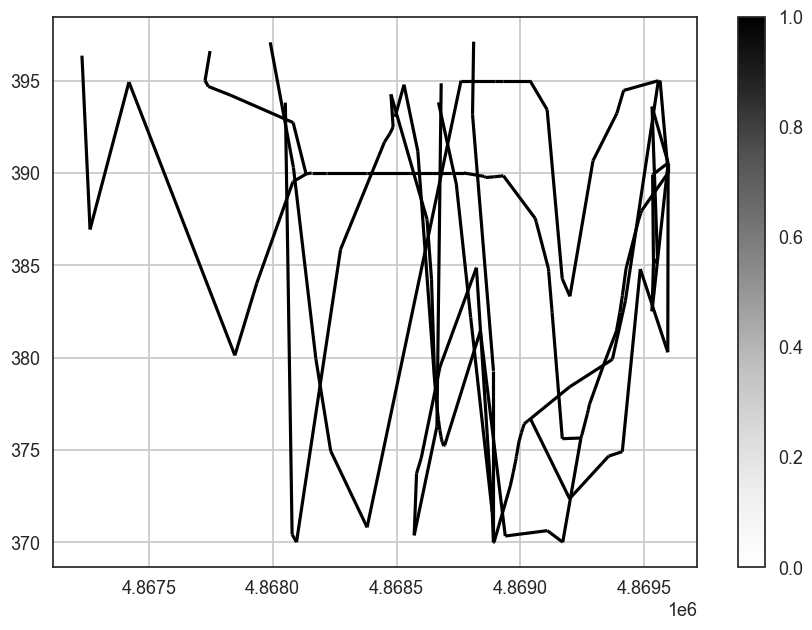

In [60]:
fig, ax = plt.subplots()
# cbar = ax.imshow(np.flipud(geo[0,:,:].T), extent = (x0, x1, z0, z1))
plot_2D_network(nodes, edges, axes = ('y','z'), ax =ax)



TypeError: unhashable type: 'Series'

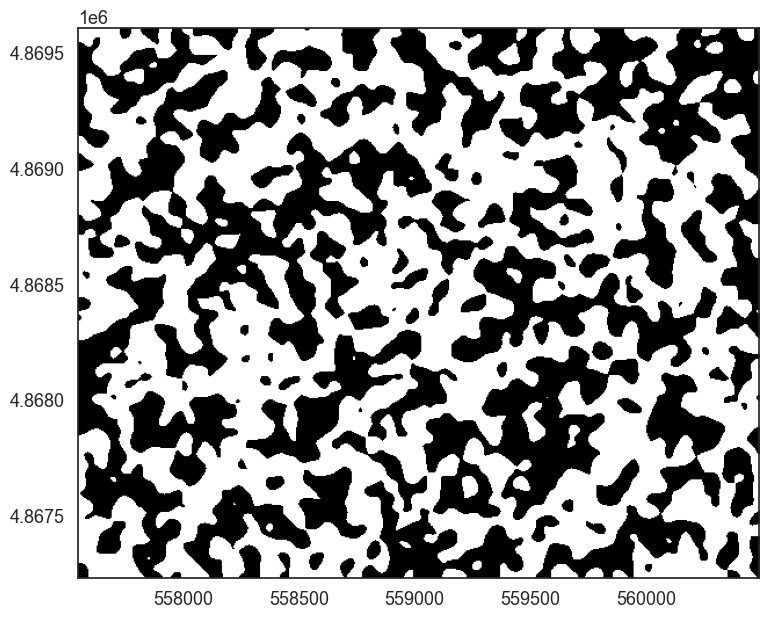

In [49]:
fig, ax = plt.subplots()
cbar = ax.imshow(np.flipud(geo[:,:,0].T), extent = (x0, x1, y0, y1))
# plt.colorbar(cbar, ax = ax, label = 'Geological Unit')
plot_2D_network(nodes, edges, ax = ax, axes = ('x', 'y'), edge_color= edges.z_1)

In [ ]:
from shapely.geometry import LineString

def check_intersection(edge1, edge2, tol = 1e-6):
    line1 = LineString([(edge1[0], edge1[1], edge1[2]), (edge1[3], edge1[4], edge1[5])])
    line2 = LineString([(edge2[0], edge2[1], edge2[2]), (edge2[3], edge2[4], edge2[5])])
    return line1.intersects(line2) and line1.intersection(line2).length > tol
    # Unpack edge coordinates

In [116]:
max_length = edges.length.max()
checked_edges = set() # keep track of edges that have already been checked for intersection to avoid redundant checks
for idx, edge in edges.iterrows():
    checked_edges.add(idx)
    edge_coord = edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values #edge coordinates
    edge_midpoint = [(edge.x_0 + edge.x_1)/2, (edge.y_0 + edge.y_1)/2, (edge.z_0 + edge.z_1)/2]
    #bounding box, limited by the max conduit length of system 
    bounds = {'x_0': min(edge.x_0, edge.x_1) - max_length, 'x_1': max(edge.x_0, edge.x_1) + max_length,
              'y_0': min(edge.y_0, edge.y_1) - max_length, 'y_1': max(edge.y_0, edge.y_1) + max_length,
              'z_0': min(edge.z_0, edge.z_1) - max_length, 'z_1': max(edge.z_0, edge.z_1) + max_length}
    #only nodes within the bounding box will be tested
    nodes_to_test = nodes[((nodes.x >= bounds['x_0']) & (nodes.x <= bounds['x_1']) &
                           (nodes.y >= bounds['y_0']) & (nodes.y <= bounds['y_1']) &
                           (nodes.z >= bounds['z_0']) & (nodes.z <= bounds['z_1']))]
    nodes_to_test = nodes_to_test[(nodes_to_test.id.isin([edge.from_id, edge.to_id]) == False)]
    edges_to_test = edges[edges.from_id.isin(nodes_to_test.id) | edges.to_id.isin(nodes_to_test.id)]
    edges_to_test = edges_to_test[~edges_to_test.index.isin(checked_edges)] #exclude edges that have already been tested in previous iterations
    for test_idx, test_edge in edges_to_test.iterrows():
        test_edge_coord = test_edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values
        if check_intersection(edge_coord, test_edge_coord):
            print(f"Edge {edge.name} intersects with edge {test_edge.name}")

(557500.0, 558500.0)

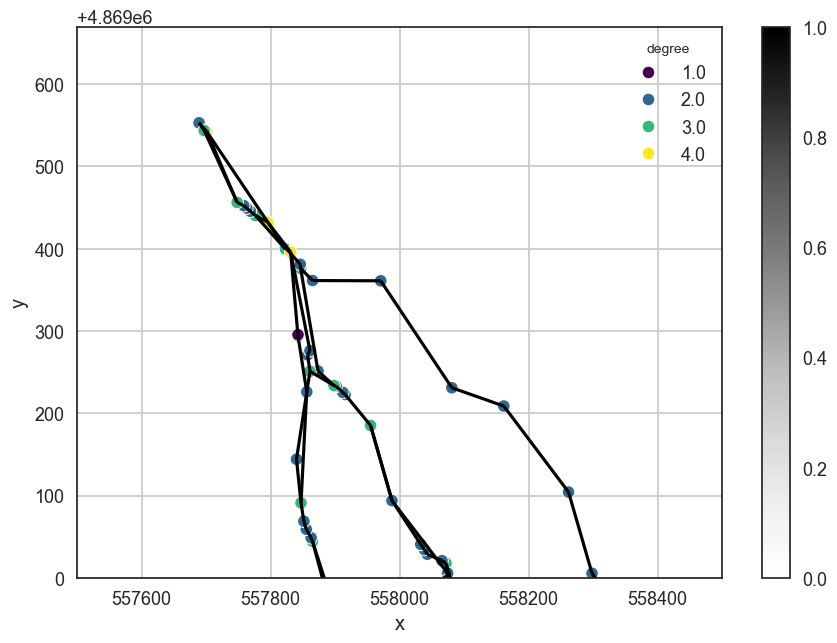

In [126]:
plot_2D_network(nodes, edges, axes = ('x', 'y'),node_color = nodes.degree)
plt.ylim(4869000,)
plt.xlim(557500,558500)


## Changing Slope

In [14]:
network_dir = '../steady_state/conduit_geometry_test/networks/anastomotic_simple_clean'
nodes = pd.read_csv(f"{network_dir}/nodes.csv")
edges = pd.read_csv(f"{network_dir}/edges.csv")
edges = conduit_lengths(nodes, edges)
edges = conduit_slopes(nodes, edges)

In [20]:
slope = 0.0008
dip = np.arctan(slope)
elevs= create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = dip, azimuth = 350, z1 = 400)

In [21]:
def calculate_azimuth(node_1, node_2):
    dx = node_1[0] - node_2[0]
    dy = node_1[1] - node_2[1]
    azimuth = np.arctan2(dy, dx)
    return azimuth

In [25]:
n1 = nodes[nodes.type =='inlet'].iloc[2][['x', 'y', 'z']]
n2 = nodes[nodes.type =='outlet'].iloc[0][['x', 'y', 'z']]
az = calculate_azimuth(n1, n2)
grid = create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = dip, azimuth = az, z1 = 400)
nodes, edges = project_conduit_elevations(nodes, edges, grid, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
# nodes.loc[nodes.type=='inlet', 'z'] = nodes.loc[nodes.type=='inlet', 'z'] + 2
edges = extract_edge_coordinates(nodes, edges)

In [26]:
plot_3D_network(nodes, edges, show_nodes = False)

In [27]:
network_dir = '../steady_state/conduit_geometry_test/networks'
save_network(nodes, edges, network_dir, 'anastomotic_low_slope')


Network saved to ../steady_state/conduit_geometry_test/networks


In [58]:
nodes_1, edges_1 = rescale_slope(nodes, edges, alpha = 0.1, reference_id = nodes[nodes.type == 'outlet'].id.iloc[0])

<Axes: >

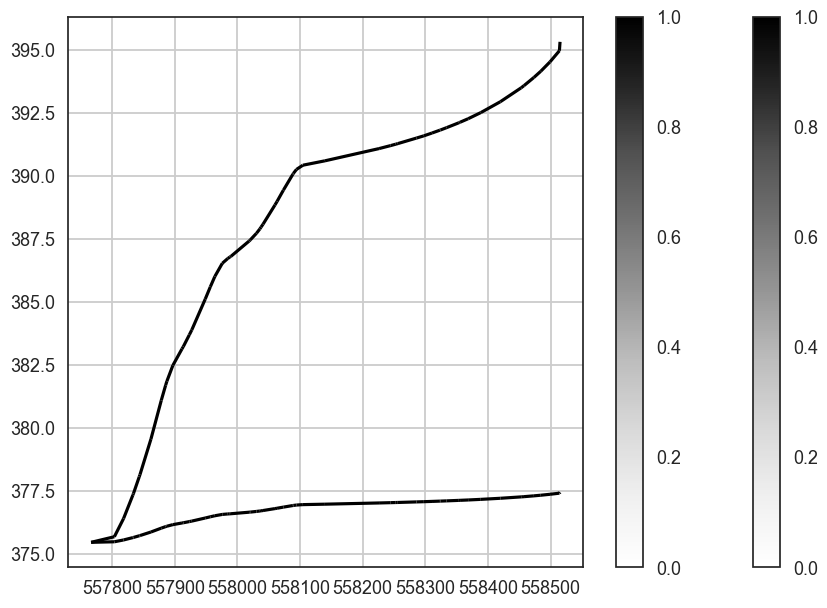

In [59]:
fig, ax = plt.subplots()
plot_2D_network(nodes, edges, axes = ('x', 'z'), ax = ax)
plot_2D_network(nodes_1, edges_1, axes = ('x', 'z'), ax = ax)

In [60]:
os.makedirs(f"{network_dir}/low_slope", exist_ok = True)
nodes_1.to_csv(f"{network_dir}/low_slope/nodes.csv", index = False)
edges_1.to_csv(f"{network_dir}/low_slope/edges.csv", index = False )

# Embedding Network in Fracture Lattice

In [27]:
buffer = 20
xmin = nodes.x.min() - buffer
xmax = nodes.x.max() + buffer
ymin = nodes.y.min() - buffer
ymax = nodes.y.max() + buffer
zmin = nodes.z.min() - buffer
zmax = nodes.z.max() + buffer
#make arrays for nodes
X, Y, Z = np.arange(xmin, xmax, dx), np.arange(ymin, ymax, dy), np.arange(zmin, zmax, dz)
lattice_x, lattice_y, lattice_z = np.meshgrid(X, Y, Z, indexing = 'ij')
lattice_nodes = pd.DataFrame({'x': lattice_x.flatten(), 'y': lattice_y.flatten(), 'z': lattice_z.flatten()})


In [6]:
cube_lattice = op.network.Cubic(shape = (nx, ny, nz), spacing = (dx, dy, dz))

In [13]:
cube_lattice.pores()

array([      0,       1,       2, ..., 1675797, 1675798, 1675799])

# Calculate Metrics

In [149]:
def bounding_box(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    z_min = nodes.z.min()
    z_max = nodes.z.max()
    return x_min, x_max, y_min, y_max, z_min, z_max
def bounding_box_2D(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    return x_min, x_max, y_min, y_max
def index(nodes, edges, mode, extent_method = 'bounding_box',verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    if mode == 'HI':
        temp_nodes['z'] = 0 # set all nodes to the same elevation to create a 2D network
        temp_edges['z_0'] = 0
        temp_edges['z_1'] = 0
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)
        print_verbose(f"Max extent, bounding box: {max_extent}", verbose)
    elif extent_method == 'straight_line':
        max_extent = 0
        for outlet in nodes[nodes.type == 'outlet'].itertuples():
            for inlet in nodes[nodes.type == 'inlet'].itertuples():
                d = np.sqrt((outlet.x - inlet.x)**2 + (outlet.y - inlet.y)**2 + (outlet.z - inlet.z)**2)
                max_extent += d
        print_verbose(f"Max extent, straight line distance: {max_extent}", verbose)           
    #TODO: other methods
    index = total_length/max_extent
    return index

def VI(nodes, edges, extent_method = 'bounding_box', verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)
        print_verbose(f"Max extent of network: {max_extent}", verbose)
    VI = total_length/max_extent
    return VI

In [256]:
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/anastomotic_3/nodes.csv")
edges = pd.read_csv("../steady_state/conduit_geometry_test/networks/anastomotic_3/edges.csv")
# simple_nodes, simple_edges = reduce_node_density(nodes, edges, 100)
# simple_nodes, simple_edges = reset_node_ids(simple_nodes, simple_edges)
network = okn.OpenKarstNetwork(nodes=nodes, edges = edges)
network.load_cave_data()
network.degree()
nodes['degree'] = network.degree
# simple_nodes['d'] = 1
# nodes['z'] = get_elev_from_coords(nodes.x, nodes.y, elevs, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
# edges = extract_edge_coordinates(nodes, edges)
# nodes.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/nodes.csv", index = False)
# edges.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/edges.csv", index = False)

In [257]:
index(nodes, edges, mode='HI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 9048.80918962809
Max extent, bounding box: 3511.2701405616745


np.float64(2.577075766714039)

In [258]:
index(nodes, edges, mode = 'VI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 9049.240406641464
Max extent, bounding box: 3511.2764382263704


np.float64(2.5771939537783735)

In [154]:
conduit_lengths(nodes, edges)

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length
0,0,11,558515.000000,4.867230e+06,398.561836,558495.772389,4.867361e+06,396.524897,132.423805
1,1,116,557954.975539,4.869185e+06,395.553991,557988.166388,4.869094e+06,395.616483,97.146446
2,1,4,557954.975539,4.869185e+06,395.553991,557915.514704,4.869223e+06,395.483555,54.480882
3,1,49,557954.975539,4.869185e+06,395.553991,557988.165951,4.869094e+06,395.616483,97.146605
4,2,120,557918.983064,4.868860e+06,395.497990,557952.000000,4.868811e+06,397.559856,59.277603
...,...,...,...,...,...,...,...,...,...
122,111,115,558298.419385,4.869006e+06,396.158921,558262.026569,4.869104e+06,396.096273,105.169889
123,112,116,558074.484185,4.869006e+06,395.766238,557988.166388,4.869094e+06,395.616483,123.480506
124,113,119,558305.447769,4.868368e+06,396.177579,558250.924683,4.868428e+06,396.080652,80.961338
125,114,117,558083.569315,4.868916e+06,395.785020,558074.845245,4.868995e+06,395.766394,79.473764


In [84]:
edges[['z_0', 'z_1']] = 0 
conduit_lengths(nodes, edges)

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length
0,0,7,558515.000000,4.867230e+06,0,558491.000000,4.867299e+06,0,72.605182
1,7,8,558491.000000,4.867299e+06,0,558467.000000,4.867367e+06,0,72.605182
2,8,9,558467.000000,4.867367e+06,0,558443.000000,4.867436e+06,0,72.605182
3,9,10,558443.000000,4.867436e+06,0,558419.000000,4.867504e+06,0,72.605182
4,10,11,558419.000000,4.867504e+06,0,558395.000000,4.867573e+06,0,72.605182
...,...,...,...,...,...,...,...,...,...
121,122,123,557824.520090,4.869253e+06,0,557812.865096,4.869290e+06,0,38.338330
122,123,124,557812.865096,4.869290e+06,0,557801.210101,4.869326e+06,0,38.338330
123,124,125,557801.210101,4.869326e+06,0,557789.555107,4.869363e+06,0,38.338330
124,125,126,557789.555107,4.869363e+06,0,557777.900112,4.869399e+06,0,38.338330


In [252]:
outlets = nodes[nodes.type == 'outlet'].id
outlet_edges = edges[edges.to_id.isin(outlets) | edges.from_id.isin(outlets)]
node_ids = set(outlet_edges.from_id.tolist() + outlet_edges.to_id.tolist())
i = 1
degrees = 3
while i < degrees: 
    outlet_edges = edges[edges.from_id.isin(node_ids) | edges.to_id.isin(node_ids)]
    node_ids |= set(outlet_edges.from_id.tolist() + outlet_edges.to_id.tolist())
    i+=1
outlet_nodes = nodes[nodes.id.isin(node_ids)]

In [244]:
outlet_nodes

,id,x,y,z,type,d,degree
28,28,557618.454397,4.869410e+06,394.965485,junction,1,3
30,30,557597.401493,4.869384e+06,394.930974,junction,1,2
33,33,557670.975346,4.869482e+06,395.051563,junction,1,3
34,34,557671.000000,4.869486e+06,395.060290,junction,1,3
35,35,557596.000000,4.869421e+06,394.930422,junction,1,2
37,37,557891.975127,4.869567e+06,395.442905,junction,1,2
40,40,557689.000000,4.869553e+06,395.085363,outlet,1,2
45,45,557808.357623,4.869590e+06,395.294242,junction,1,2
52,52,557760.146555,4.869556e+06,395.207531,junction,1,2
59,59,557678.312674,4.869496e+06,395.068858,junction,1,2


In [245]:
outlet_edges

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1
38,28.0,33.0,557618.454397,4.869410e+06,394.965485,557670.975346,4.869482e+06,395.051563
42,30.0,35.0,557597.401493,4.869384e+06,394.930974,557596.000000,4.869421e+06,394.930422
45,33.0,34.0,557670.975346,4.869482e+06,395.051563,557671.000000,4.869486e+06,395.060290
46,33.0,59.0,557670.975346,4.869482e+06,395.051563,557678.312674,4.869496e+06,395.068858
48,34.0,35.0,557671.000000,4.869486e+06,395.060290,557596.000000,4.869421e+06,394.930422
50,37.0,45.0,557891.975127,4.869567e+06,395.442905,557808.357623,4.869590e+06,395.294242
55,40.0,52.0,557689.000000,4.869553e+06,395.085363,557760.146555,4.869556e+06,395.207531
60,45.0,52.0,557808.357623,4.869590e+06,395.294242,557760.146555,4.869556e+06,395.207531
156,34.0,40.0,557671.000000,4.869486e+06,395.060290,557689.000000,4.869553e+06,395.085363


<Axes: xlabel='x', ylabel='y'>

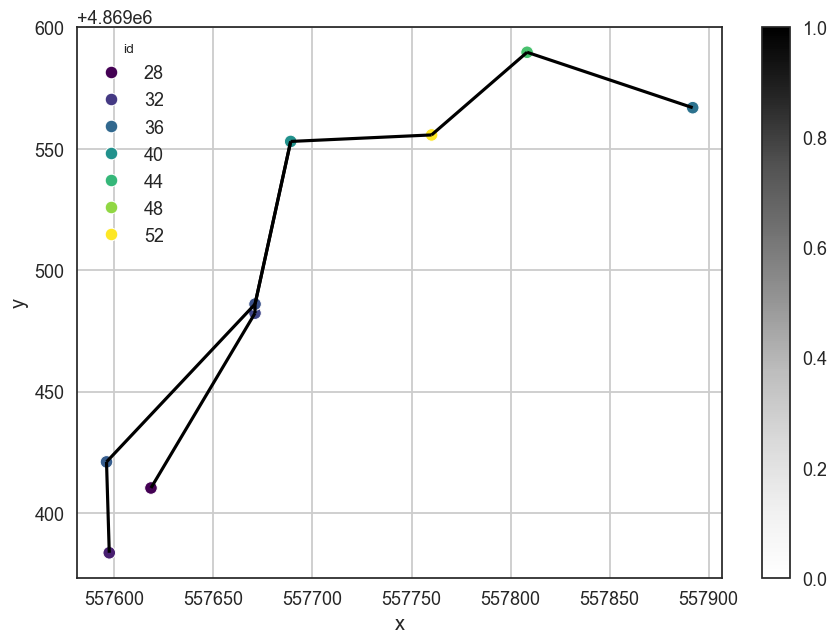

In [253]:
plot_2D_network(nodes[nodes.id.isin(node_ids)], outlet_edges,node_color = nodes[nodes.id.isin(node_ids)].id)


(4869400.0, 4869600.0)

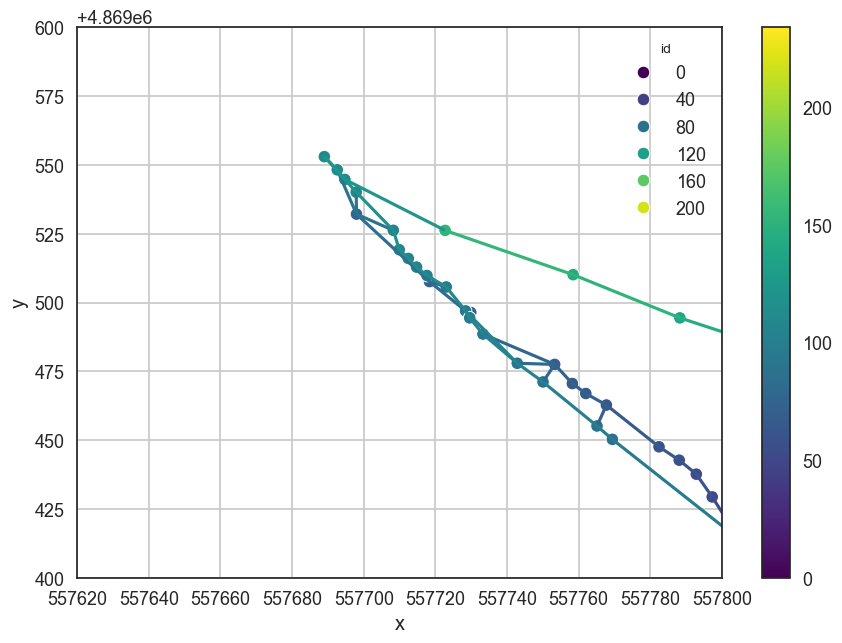

In [259]:
plot_2D_network(nodes, edges, axes = ('x', 'y'), 
                edge_color=edges.index, node_color = nodes.id, 
                palette = 'viridis')
plt.xlim(557620, 557800)
plt.ylim(4869400, 4869600)